# Exploratory Data Analysis (EDA)
## Car Price Prediction Dataset

This notebook provides comprehensive exploratory data analysis of the car price prediction dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../data/car_price_prediction_.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (2500, 10)


## 1. Dataset Overview

In [2]:
# Display basic information
print("First few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

First few rows:
   Car ID  Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition  \
0       1  Tesla  2016          2.3    Petrol       Manual   114832       New   
1       2    BMW  2018          4.4  Electric       Manual   143190      Used   
2       3   Audi  2013          4.5  Electric       Manual   181601       New   
3       4  Tesla  2011          4.1    Diesel    Automatic    68682       New   
4       5   Ford  2009          2.6    Diesel       Manual   223009  Like New   

      Price     Model  
0  26613.92   Model X  
1  14679.61  5 Series  
2  44402.61        A4  
3  86374.33   Model Y  
4  73577.10   Mustang  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size

In [3]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values:")
print(missing[missing > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
Series([], dtype: int64)

Total missing: 0


## 2. Price Distribution Analysis

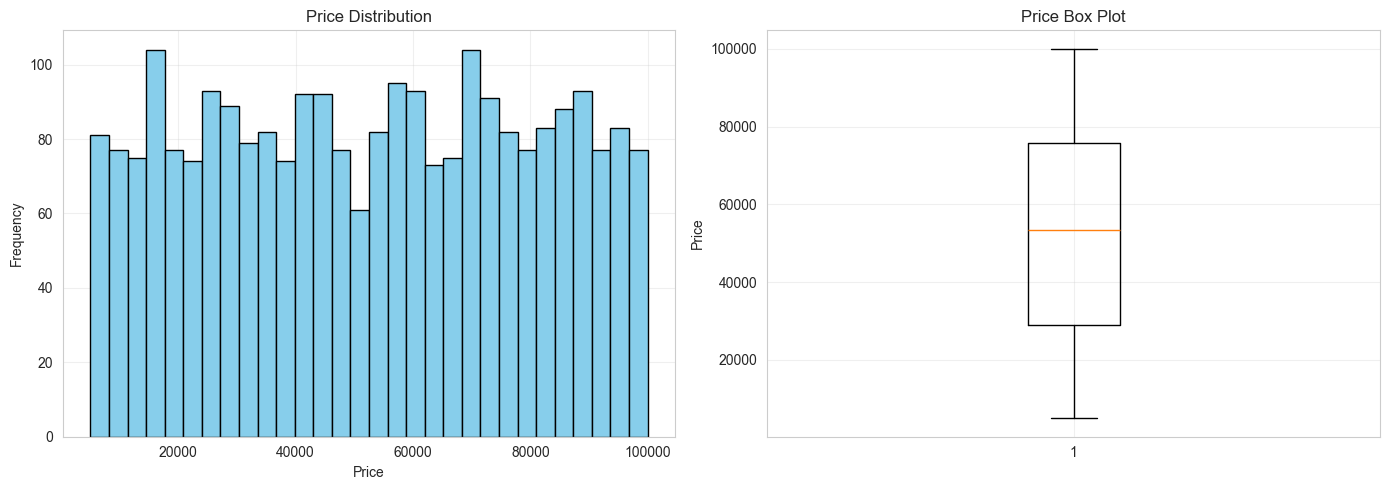

Mean Price: $52,638.02
Median Price: $53,485.24
Std Dev: $27,295.83
Min Price: $5,011.27
Max Price: $99,982.59


In [4]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Price'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['Price'])
axes[1].set_ylabel('Price')
axes[1].set_title('Price Box Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print(f"Mean Price: ${df['Price'].mean():,.2f}")
print(f"Median Price: ${df['Price'].median():,.2f}")
print(f"Std Dev: ${df['Price'].std():,.2f}")
print(f"Min Price: ${df['Price'].min():,.2f}")
print(f"Max Price: ${df['Price'].max():,.2f}")

## 3. Numerical Features Analysis

Correlation with Price:
Price          1.000000
Car ID         0.004650
Engine Size   -0.004420
Mileage       -0.008567
Year          -0.036805
Name: Price, dtype: float64


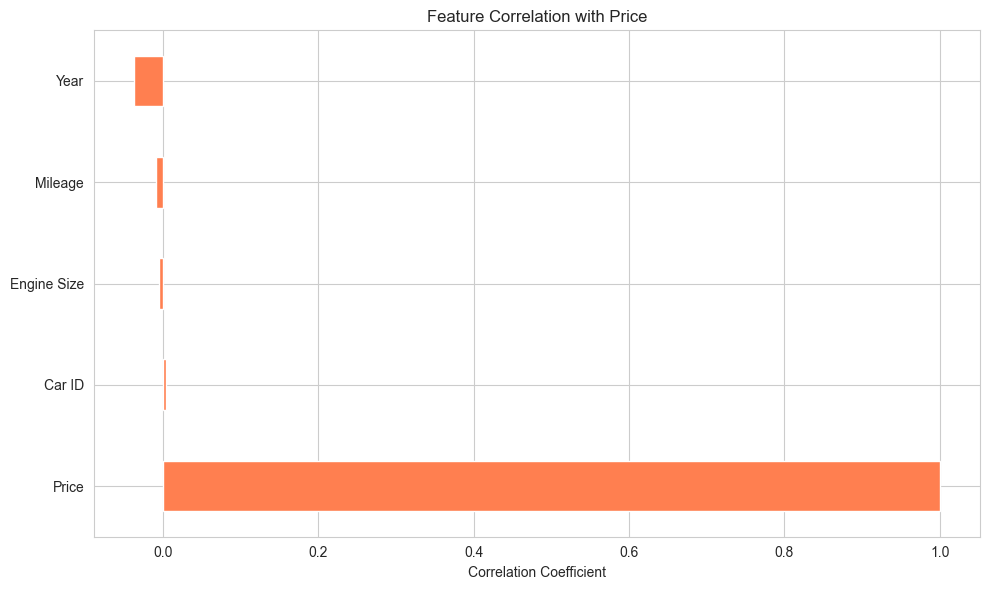

In [5]:
# Correlation with price
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numerical_cols].corr()['Price'].sort_values(ascending=False)

print("Correlation with Price:")
print(correlations)

# Visualize correlations
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color='coral')
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlation with Price')
plt.tight_layout()
plt.show()

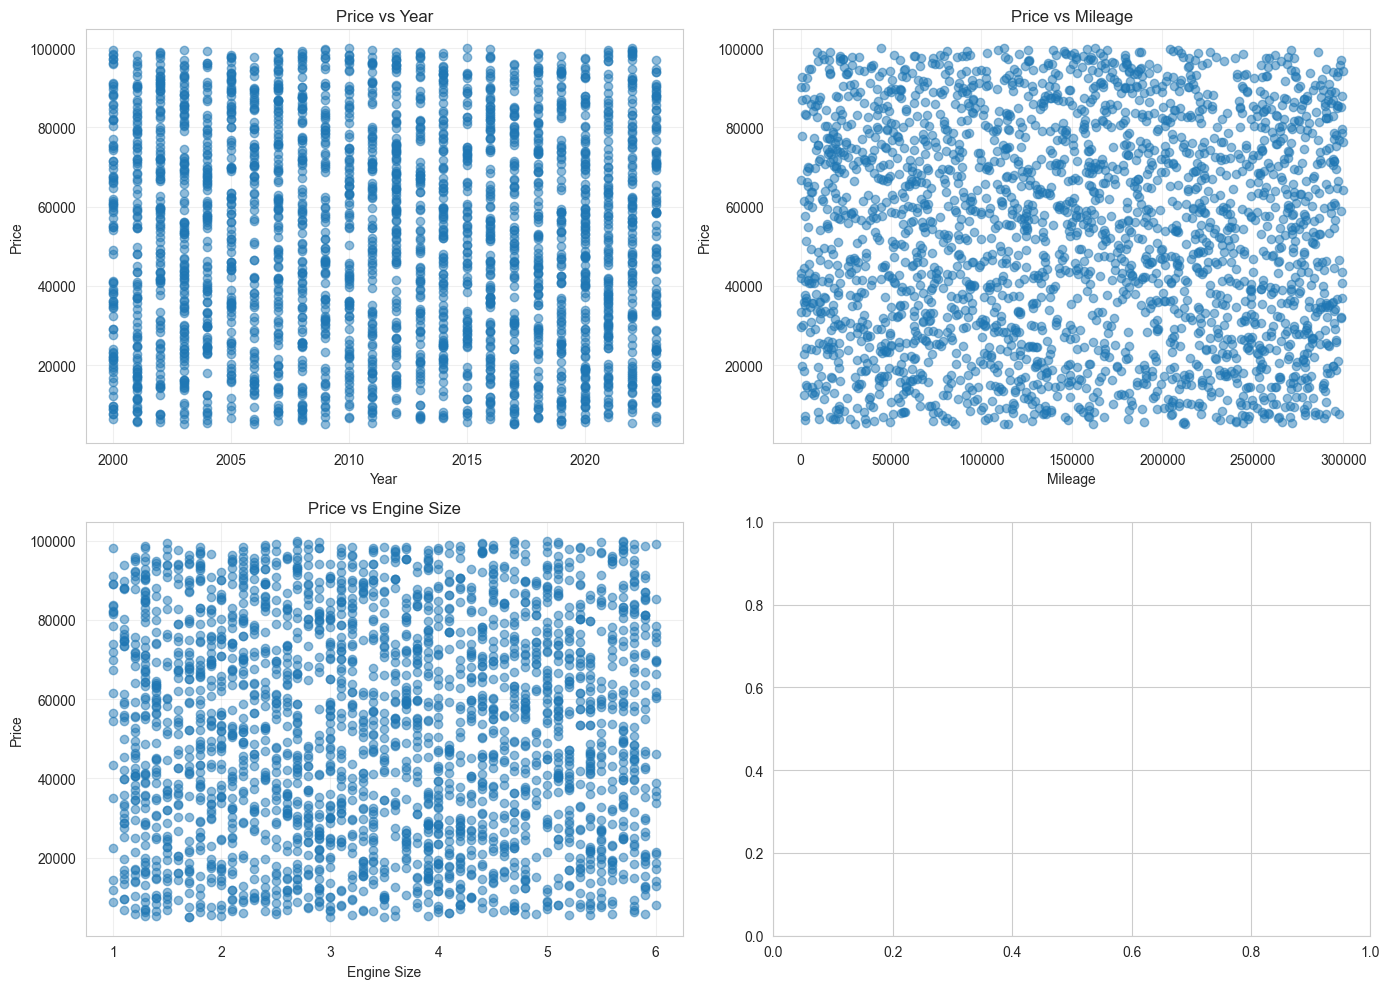

In [6]:
# Scatter plots for top features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

top_features = ['Year', 'Mileage', 'Engine Size', 'Asking Price']

for idx, feature in enumerate(top_features):
    if feature in df.columns:
        axes[idx].scatter(df[feature], df['Price'], alpha=0.5)
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Price')
        axes[idx].set_title(f'Price vs {feature}')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Categorical Features Analysis

In [7]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Features:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Categorical Features:

Brand:
Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

Fuel Type:
Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64

Transmission:
Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64

Condition:
Condition
Used        855
Like New    836
New         809
Name: count, dtype: int64

Model:
Model
Fiesta      103
Corolla     103
A3           98
A4           96
CR-V         95
Q7           95
5 Series     93
Model X      93
Prius        93
3 Series     93
X3           92
GLA          92
C-Class      92
Camry        90
E-Class      89
Model Y      89
Fit          89
RAV4         88
Accord       88
Model 3      87
Explorer     86
Focus        81
GLC          80
Civic        80
X5           80
Model S      79
Q5           79
Mustang      77
Name: count, dtype: int64


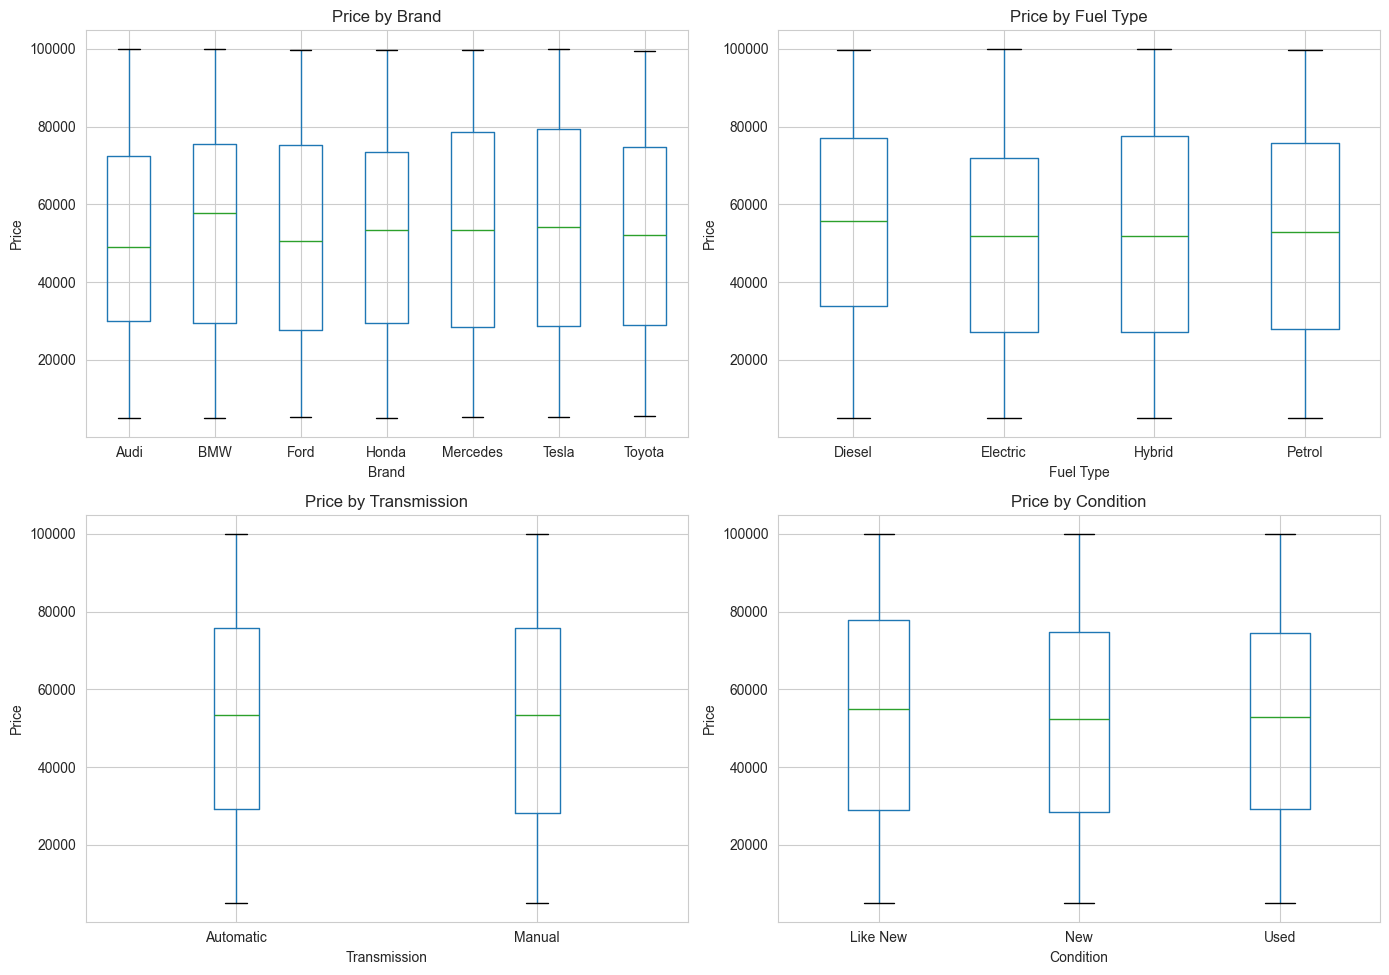

In [8]:
# Price by categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

categorical_features = ['Brand', 'Fuel Type', 'Transmission', 'Condition']

for idx, feature in enumerate(categorical_features):
    if feature in df.columns:
        df.boxplot(column='Price', by=feature, ax=axes[idx])
        axes[idx].set_title(f'Price by {feature}')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Price')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Correlation Matrix Heatmap

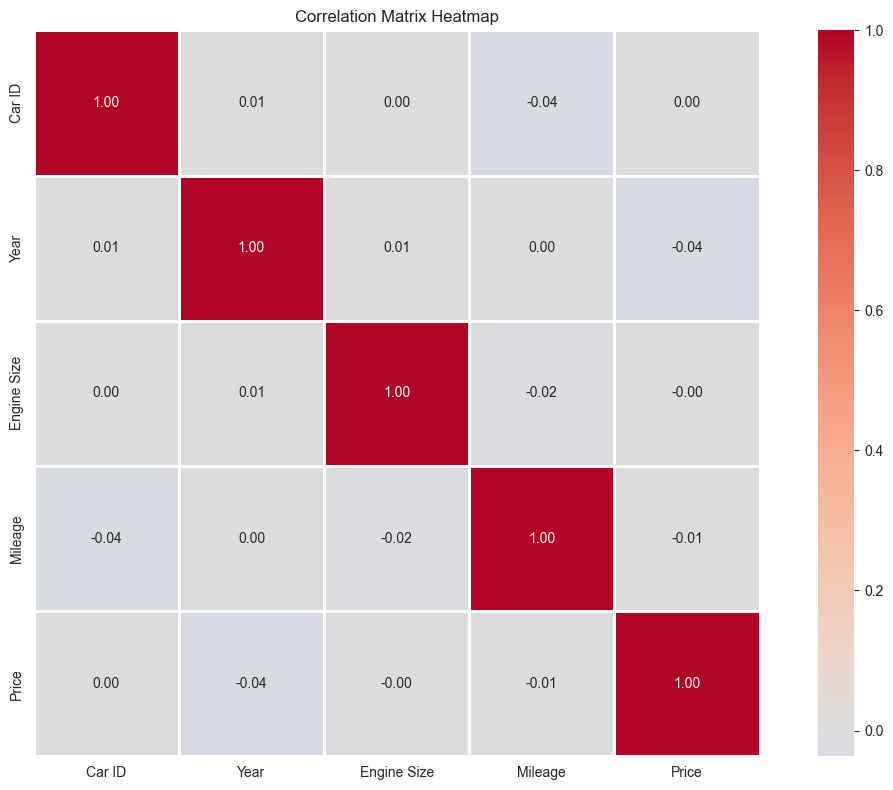

In [9]:
# Create correlation matrix
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

## 6. Outlier Detection

In [10]:
# Outlier detection using IQR method
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numerical_cols:
    outliers, lower, upper = detect_outliers(df, col)
    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Outliers found: {len(outliers)}")
        print(f"  Range: [{lower:.2f}, {upper:.2f}]")

## 7. Key Insights

In [11]:
# Summary insights
print("="*50)
print("KEY INSIGHTS FROM EDA")
print("="*50)
print(f"\n1. Dataset Size: {len(df)} records, {len(df.columns)} features")
print(f"\n2. Target Variable (Price):")
print(f"   - Range: ${df['Price'].min():,.0f} - ${df['Price'].max():,.0f}")
print(f"   - Mean: ${df['Price'].mean():,.0f}")

print(f"\n3. Most Important Features (by correlation):")
for i, (feat, corr) in enumerate(correlations.head(6).items(), 1):
    if feat != 'Price':
        print(f"   {i}. {feat}: {corr:.3f}")

print(f"\n4. Data Quality:")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Complete rows: {len(df) - df.isnull().any(axis=1).sum()}")
print(f"   - Completeness: {(1 - df.isnull().sum().sum()/(len(df)*len(df.columns)))*100:.1f}%")

KEY INSIGHTS FROM EDA

1. Dataset Size: 2500 records, 10 features

2. Target Variable (Price):
   - Range: $5,011 - $99,983
   - Mean: $52,638

3. Most Important Features (by correlation):
   2. Car ID: 0.005
   3. Engine Size: -0.004
   4. Mileage: -0.009
   5. Year: -0.037

4. Data Quality:
   - Missing values: 0
   - Complete rows: 2500
   - Completeness: 100.0%
